# Generate Q,K,V

Embedding

↓

Query

↓

"What am I looking for?"

Embedding

↓

Key

↓

"What information do I have?"

Embedding

↓

Value

↓

"What information should I send?"


```
                 Embedding

                     │

      ┌──────────────┼──────────────┐

      ▼              ▼              ▼

      Q              K              V

Question         Identity       Information
```



Let's search in the Fb

You search for **Rahim**

Search Box-->Query

Database-->Key

Profile---.value



```
Matching
Query * key --> Best Match--> Return value
```





```
Embedding X

Shape

4×4

         │

 ┌───────┼────────┐

 ▼       ▼        ▼

WQ       WK       WV ---> This are the trainable paramneter..all are (4,4) matrix

 ▼       ▼        ▼

Q        K        V
(4,4)   (4,4)    (4,4) --->Q,K,V dimension
```



In [1]:
import torch
import torch.nn as nn

torch.manual_seed(42)



vocab = {
    "<PAD>":0,
    "<UNK>":1,
    "I":2,
    "love":3,
    "deep":4,
    "learning":5
}



embedding = nn.Embedding(
    num_embeddings=len(vocab),
    embedding_dim=4
)

token_ids = torch.tensor([2,3,4,5])

X = embedding(token_ids)

print("="*60)
print("Embedding Output (X)")
print("="*60)
print(X)
print("Shape :", X.shape)

Embedding Output (X)
tensor([[ 0.3559, -0.6866, -0.4934,  0.2415],
        [-1.1109,  0.0915, -2.3169, -0.2168],
        [-0.3097, -0.3957,  0.8034, -0.6216],
        [-0.5920, -0.0631, -0.8286,  0.3309]], grad_fn=<EmbeddingBackward0>)
Shape : torch.Size([4, 4])


## Query,Key,Value layers

In [2]:
query_layer = nn.Linear(4,4,bias=False)
key_layer   = nn.Linear(4,4,bias=False)
value_layer = nn.Linear(4,4,bias=False)
print("Wq",query_layer.weight)
print("Wk",key_layer.weight)
print("Wv",value_layer.weight)

Wq Parameter containing:
tensor([[ 0.1343, -0.1356,  0.2104,  0.4464],
        [ 0.2890, -0.2186,  0.2886,  0.0895],
        [ 0.2539, -0.3048, -0.4950, -0.1932],
        [-0.3835,  0.4103,  0.1440,  0.2071]], requires_grad=True)
Wk Parameter containing:
tensor([[ 0.1581, -0.0087,  0.3913, -0.3553],
        [ 0.0315, -0.3413,  0.1542, -0.1722],
        [ 0.1532, -0.1042,  0.4147, -0.2964],
        [-0.2982, -0.2982,  0.4497,  0.1666]], requires_grad=True)
Wv Parameter containing:
tensor([[ 0.4811, -0.4126, -0.4959, -0.3912],
        [-0.3363,  0.2025,  0.1790,  0.4155],
        [-0.2582, -0.3409,  0.2653, -0.2021],
        [ 0.3035, -0.1187,  0.2860, -0.3885]], requires_grad=True)


## Generate Q,K,V

In [3]:
Q = query_layer(X)
K = key_layer(X)
V = value_layer(X)

print("\n"+"="*60)
print("Query Matrix (Q)")
print("="*60)
print(Q)
print("Shape :", Q.shape)

print("\n"+"="*60)
print("Key Matrix (K)")
print("="*60)
print(K)
print("Shape :", K.shape)

print("\n"+"="*60)
print("Value Matrix (V)")
print("="*60)
print(V)
print("Shape :", V.shape)


Query Matrix (Q)
tensor([[ 0.1449,  0.1321,  0.4971, -0.4392],
        [-0.7460, -1.0292,  0.8787,  0.0850],
        [-0.0964,  0.1733, -0.2356, -0.0566],
        [-0.0976, -0.3669,  0.2151,  0.1504]], grad_fn=<MmBackward0>)
Shape : torch.Size([4, 4])

Key Matrix (K)
tensor([[-0.2166,  0.1279, -0.1501, -0.0830],
        [-1.0061, -0.3861, -1.0763, -0.7741],
        [ 0.4897,  0.3562,  0.5111,  0.4681],
        [-0.5348, -0.1818, -0.5258, -0.1221]], grad_fn=<MmBackward0>)
Shape : torch.Size([4, 4])

Value Matrix (V)
tensor([[ 0.6047, -0.2467, -0.0375, -0.0455],
        [ 0.6616, -0.1127, -0.3152, -0.9264],
        [-0.1410, -0.0904,  0.5536,  0.4242],
        [ 0.0227,  0.1755, -0.1123, -0.5377]], grad_fn=<MmBackward0>)
Shape : torch.Size([4, 4])


## Final Shape Summary



```
Token IDs
        (4,)
          │
          ▼
Embedding
      (4,4)
          │
   ┌──────┼──────┐
   ▼      ▼      ▼
Q(4,4)  K(4,4)  V(4,4)
```



# Attention Score = QK^t



```
Embedding
    │
    ▼
Q      K      V
│      │
└──┬───┘
   ▼
Q × Kᵀ
   │
   ▼
Attention Score Matrix
```



In [4]:
attention_scores = Q @ K.T
print("="*60)
print("Q Shape :",Q.shape)

print("K Shape :",K.shape)

print("Attention Score Shape :",attention_scores.shape)

print("="*60)

print(attention_scores)

Q Shape : torch.Size([4, 4])
K Shape : torch.Size([4, 4])
Attention Score Shape : torch.Size([4, 4])
tensor([[-0.0527, -0.3919,  0.1665, -0.3093],
        [-0.1090,  0.1363, -0.2430,  0.1137],
        [ 0.0831,  0.3275, -0.1324,  0.1508],
        [-0.0705, -0.1080,  0.0019, -0.0125]], grad_fn=<MmBackward0>)




```
                 Keys
             I   love  deep  learning
Queries
I          0.24 -0.71  0.32  -0.30
love       0.47 -0.99  0.67  -0.48
deep       0.04  0.09 -0.05   0.07
learning   0.14 -0.47  0.24  -0.21
```





---
this are similarity score



## Attention wights

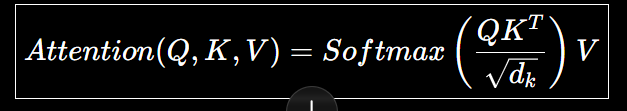

## scaling



```
কেন Scaling?

ধরো

Embedding Dimension

512

তাহলে একটা Query Vector

[2.1
0.4
-1.8
...
512 numbers]

Key Vector

[-0.2
3.1
...
512 numbers]

Dot Product

Q⋅K

হতে পারে

380

425

510

450

এত বড় Number কেন হয়?

কারণ

512টা Multiplication হচ্ছে।

ছোট Example

ধরো

Query

[2
3
4
5]

Key

[1
2
3
4]

Dot Product

2×1+3×2+4×3+5×4

=

2+6+12+20

=

40

Embedding যদি 512 হয়

Dot Product অনেক বড় হবে।

Problem

Softmax বড় Number পছন্দ করে না।

Example

Scores

[400

405

410]

Softmax

e
400
+e
405
+e
410
e
400
	​


Output

প্রায়

[0

0

1]

এটাকে বলে

Peaky Distribution

মানে

একটাই Word সব Attention নিয়ে নিল।

Training খারাপ হবে।

তাই Transformer কী করে?

Divide করে

(dk)^0.5
	​

	​


যেখানে

dk=Key Dimension

Example

যদি

d_k=4

তাহলে

(4)^0.5=2

আগে

[20

30

40]

Divide

2

পরে

[10

15

20]

Softmax এখন অনেক Stable হবে।
```



In [5]:
# dk=4
# dk=(4)*0.5=2
import math
dk = K.shape[-1]

scaled_scores = attention_scores / math.sqrt(dk)

print("\nScaled Scores")
print(scaled_scores)


Scaled Scores
tensor([[-0.0263, -0.1959,  0.0833, -0.1546],
        [-0.0545,  0.0682, -0.1215,  0.0569],
        [ 0.0415,  0.1637, -0.0662,  0.0754],
        [-0.0353, -0.0540,  0.0009, -0.0063]], grad_fn=<DivBackward0>)


dim=-1?

PyTorch

torch.softmax(
scores,
dim=-1
)

মানে

Last Dimension

অর্থাৎ

প্রত্যেক Row-এর মধ্যে Softmax হবে।

In [6]:
attention_weights = torch.softmax(
    scaled_scores,
    dim=-1
)
print(attention_weights)

tensor([[0.2605, 0.2198, 0.2906, 0.2291],
        [0.2390, 0.2702, 0.2235, 0.2672],
        [0.2462, 0.2782, 0.2210, 0.2546],
        [0.2471, 0.2425, 0.2562, 0.2543]], grad_fn=<SoftmaxBackward0>)


In [8]:
print(attention_weights.shape)

torch.Size([4, 4])


## Summary From embeddings to attention wights



```
Sentence
      │
      ▼
Embedding
      │
      ▼
X
      │
 ┌────┼────┐
 ▼    ▼    ▼
Q     K     V
 │
 ▼
QKᵀ
 │
 ▼
÷ √dk
 │
 ▼
Softmax
 │
 ▼
Attention Weights
```



| Step      | Shape | Meaning                                |
| --------- | ----- | -------------------------------------- |
| X         | (4,4) | Word Embeddings                        |
| Q         | (4,4) | Queries                                |
| K         | (4,4) | Keys                                   |
| V         | (4,4) | Values                                 |
| QKᵀ       | (4,4) | Raw Similarity Scores                  |
| QKᵀ / √dk | (4,4) | Scaled Scores                          |
| Softmax   | (4,4) | Attention Weights (Each row sums to 1) |


# Context vector (Context=Attention Weights×V​)

In [10]:
context = attention_weights @ V
print("Context Vector")
print(context)

print("Shape :",context.shape)

Context Vector
tensor([[ 0.2672, -0.0751,  0.0561, -0.2154],
        [ 0.2979, -0.0628, -0.0004, -0.3101],
        [ 0.3075, -0.0674, -0.0032, -0.3121],
        [ 0.2795, -0.0668,  0.0276, -0.2639]], grad_fn=<MmBackward0>)
Shape : torch.Size([4, 4])


**Context Vector (Final Output of Self-Attention)**



---

---
Z.I. Turjo


